Reference: https://maartengr.github.io/BERTopic/index.html#installation

In [150]:
from bertopic import BERTopic
import math
import ssl
import pandas as pd
from umap import UMAP
from typing import List, Union
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import plotly.express as px
import plotly.graph_objects as go

# Disable SSL verification - because it is annoying
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_20newsgroups
docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']

In [81]:
#data 
df = pd.read_csv('../output/jury_output_chat_level.csv')
df['message'] = df['message'].astype(str)

In [130]:
'''
Load the datasets at join them convert the message column into strings. 
'''

df_csop1 = pd.read_csv('../output/csop_output_chat_level.csv')
df_csop2 = pd.read_csv('../output/csopII_output_chat_level.csv')
df_csop = df_csop1.append(df_csop2, ignore_index=True)

df_jury = pd.read_csv('../output/jury_output_chat_level.csv')

df_csop['message'] = df_csop['message'].astype(str)
df_jury['message'] = df_jury['message'].astype(str)


In [84]:
'''
Fit the model based on the message column. Each message is a document 
'''
def fit_model(df):
    documents = df['message'].tolist()
    model = BERTopic()
    topics = model.fit_transform(documents)
    return model

In [85]:
'''
Get the top n topics from the model
Uncomment the print statements to see the words in the top topics
'''
def get_top_topics(topic_model,n):

    return_list = []

    for i in range(0, n): 

        topic_list = topic_model.get_topic(i)
        # print("Topic Number "+str(i))
        word_list = []

        for key,value in topic_list:
            word_list.append(key)
            print(key)
        # print("-------------------")
        return_list.append(word_list)  

    return return_list  
     

In [86]:
def visualize_topics(topic_model,
                     topics: List[int] = None,
                     top_n_topics: int = None,
                     custom_labels: Union[bool, str] = False,
                     title: str = "<b>Intertopic Distance Map</b>",
                     width: int = 650,
                     height: int = 650) -> go.Figure:
    """ Visualize topics, their sizes, and their corresponding words

    This visualization is highly inspired by LDAvis, a great visualization
    technique typically reserved for LDA.

    Arguments:
        topic_model: A fitted BERTopic instance.
        topics: A selection of topics to visualize
        top_n_topics: Only select the top n most frequent topics
        custom_labels: If bool, whether to use custom topic labels that were defined using 
                       `topic_model.set_topic_labels`.
                       If `str`, it uses labels from other aspects, e.g., "Aspect1".
        title: Title of the plot.
        width: The width of the figure.
        height: The height of the figure.

    Examples:

    To visualize the topics simply run:

    ```python
    topic_model.visualize_topics()
    ```

    Or if you want to save the resulting figure:

    ```python
    fig = topic_model.visualize_topics()
    fig.write_html("path/to/file.html")
    ```
    <iframe src="../../getting_started/visualization/viz.html"
    style="width:1000px; height: 680px; border: 0px;""></iframe>
    """
    # Select topics based on top_n and topics args
    freq_df = topic_model.get_topic_freq()
    freq_df = freq_df.loc[freq_df.Topic != -1, :]
    if topics is not None:
        topics = list(topics)
    elif top_n_topics is not None:
        topics = sorted(freq_df.Topic.to_list()[:top_n_topics])
    else:
        topics = sorted(freq_df.Topic.to_list())

    # Extract topic words and their frequencies
    topic_list = sorted(topics)
    frequencies = [topic_model.topic_sizes_[topic] for topic in topic_list]
    if isinstance(custom_labels, str):
        words = [[[str(topic), None]] + topic_model.topic_aspects_[custom_labels][topic] for topic in topic_list]
        words = ["_".join([label[0] for label in labels[:4]]) for labels in words]
        words = [label if len(label) < 30 else label[:27] + "..." for label in words]
    elif custom_labels and topic_model.custom_labels_ is not None:
        words = [topic_model.custom_labels_[topic + topic_model._outliers] for topic in topic_list]
    else:
        words = [" | ".join([word[0] for word in topic_model.get_topic(topic)[:5]]) for topic in topic_list]

    # Embed c-TF-IDF into 2D
    all_topics = sorted(list(topic_model.get_topics().keys()))
    indices = np.array([all_topics.index(topic) for topic in topics])

    if topic_model.topic_embeddings_ is not None:
        embeddings = topic_model.topic_embeddings_[indices]
        embeddings = UMAP(n_neighbors=2, n_components=2, metric='cosine', random_state=42).fit_transform(embeddings)
    else:
        embeddings = topic_model.c_tf_idf_.toarray()[indices]
        embeddings = MinMaxScaler().fit_transform(embeddings)
        embeddings = UMAP(n_neighbors=2, n_components=2, metric='hellinger', random_state=42).fit_transform(embeddings)

    # Visualize with plotly
    df = pd.DataFrame({"x": embeddings[:, 0], "y": embeddings[:, 1],
                       "Topic": topic_list, "Words": words, "Size": frequencies})
    return _plotly_topic_visualization(df, topic_list, title, width, height)
def _plotly_topic_visualization(df: pd.DataFrame,
                                topic_list: List[str],
                                title: str,
                                width: int,
                                height: int):
    """ Create plotly-based visualization of topics with a slider for topic selection """

    def get_color(topic_selected):
        if topic_selected == -1:
            marker_color = ["#B0BEC5" for _ in topic_list]
        else:
            marker_color = ["red" if topic == topic_selected else "#B0BEC5" for topic in topic_list]
        return [{'marker.color': [marker_color]}]

    # Prepare figure range
    x_range = (df.x.min() - abs((df.x.min()) * .15), df.x.max() + abs((df.x.max()) * .15))
    y_range = (df.y.min() - abs((df.y.min()) * .15), df.y.max() + abs((df.y.max()) * .15))

    # Plot topics
    fig = px.scatter(df, x="x", y="y", size="Size", size_max=40, template="simple_white", labels={"x": "", "y": ""},
                     hover_data={"Topic": True, "Words": True, "Size": True, "x": False, "y": False})
    fig.update_traces(marker=dict(color="#B0BEC5", line=dict(width=2, color='DarkSlateGrey')))

    # Update hover order
    fig.update_traces(hovertemplate="<br>".join(["<b>Topic %{customdata[0]}</b>",
                                                 "%{customdata[1]}",
                                                 "Size: %{customdata[2]}"]))

    # Create a slider for topic selection
    steps = [dict(label=f"Topic {topic}", method="update", args=get_color(topic)) for topic in topic_list]
    sliders = [dict(active=0, pad={"t": 50}, steps=steps)]

    # Stylize layout
    fig.update_layout(
        title={
            'text': f"{title}",
            'y': .95,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': dict(
                size=22,
                color="Black")
        },
        width=width,
        height=height,
        hoverlabel=dict(
            bgcolor="white",
            font_size=16,
            font_family="Rockwell"
        ),
        xaxis={"visible": False},
        yaxis={"visible": False},
        sliders=sliders
    )

    # Update axes ranges
    fig.update_xaxes(range=x_range)
    fig.update_yaxes(range=y_range)

    # Add grid in a 'plus' shape
    fig.add_shape(type="line",
                  x0=sum(x_range) / 2, y0=y_range[0], x1=sum(x_range) / 2, y1=y_range[1],
                  line=dict(color="#CFD8DC", width=2))
    fig.add_shape(type="line",
                  x0=x_range[0], y0=sum(y_range) / 2, x1=x_range[1], y1=sum(y_range) / 2,
                  line=dict(color="#9E9E9E", width=2))
    fig.add_annotation(x=x_range[0], y=sum(y_range) / 2, text="D1", showarrow=False, yshift=10)
    fig.add_annotation(y=y_range[1], x=sum(x_range) / 2, text="D2", showarrow=False, xshift=10)
    fig.data = fig.data[::-1]

    return fig

In [87]:
# fitting the models
model_jury = fit_model(df_jury)
model_csop = fit_model(df_csop)

In [88]:
# #For CSOP
# get_top_topics(model_csop,3)
# visualize_topics(model_csop, None, None,False,"<b>Intertopic Distance Map - CSOP</b>",650,650)

In [126]:
# #For Juries
top_topics = get_top_topics(model_jury,3)
# visualize_topics(model_jury, None, None,False,"<b>Intertopic Distance Map - Jury</b>",650,650)

In [125]:
'''
Divides the conversation into n equal chunks of time and adds a label for each chunk
'''
def create_chunks(df,num_chunks):
    last_row_index = df.index[-1]
    first_row_index = df.index[0]

    # Calculate the total duration
    total_duration = pd.to_datetime(df.loc[last_row_index, 'timestamp']) - pd.to_datetime(df.loc[first_row_index, 'timestamp'])

    # Calculate the duration of each chunk
    chunk_duration = total_duration / num_chunks

    # Add a new column for chunk number
    df['chunk'] = -1  

    # Assign the chunk number for each row
    for index, row in df.iterrows():
        timestamp = pd.to_datetime(row['timestamp'])
        chunk_number =int((timestamp - pd.to_datetime(df['timestamp'].min())) / chunk_duration)
        df.at[index, 'chunk'] = chunk_number


In [153]:
'''
Creates count vectors for the messages in a given DF
'''
def create_vectors(df):
    # # Create an instance of CountVectorizer
    # vectorizer = CountVectorizer()

    # # Fit the vectorizer to the text data and transform the text into count vectors
    # count_vectors = vectorizer.fit_transform(df['message'])

    # # Convert the count vectors to a DataFrame
    # return pd.DataFrame(count_vectors.toarray(), columns=vectorizer.get_feature_names_out())

    # Create an instance of TfidfVectorizer
    vectorizer = TfidfVectorizer()

    # Fit the vectorizer to the corpus and transform the documents
    tfidf_vectors = vectorizer.fit_transform(df['message'])

    # Convert the sparse matrix to a dense array for easier handling
    return pd.DataFrame(tfidf_vectors.toarray(), columns=vectorizer.get_feature_names_out())

In [ ]:
'''
Calculate the average vector for the DF
'''
def get_conv_vec_avg(vector_df):
    
    # Calculate the column means
    column_means = vector_df.mean()

    # Calculate the mean of the column means
    return column_means.mean()

In [127]:
'''
Get the average vector values for each topic
'''
def get_average_vector_for_topics(top_topics,vectors_df):
   
    topic_avg_list = []

    #for all the top topics
    for i in range(0,len(top_topics)): 
        
        #get the list of words in a given topic
        topics_list = top_topics[i]

        topic_avg_list_per_topic = []
        
        #iterate through the list of topics
        for j in range(0,len(topics_list)): 
            
            #if the topic exists in the df,
            if topics_list[j] in vectors_df.columns:

                #get the mean of the count vector for that topic
                mean = vectors_df[topics_list[j]].mean()

                #add the mean to the average vectors list for that topic
                topic_avg_list_per_topic.append(mean)
            else:

                #if the topic is not found in the df, add 0
                topic_avg_list_per_topic.append(0)
        
        #Append the list of average vectors for the given topic to the larger list
        topic_avg_list.append(topic_avg_list_per_topic)

    return topic_avg_list        

In [ ]:
'''
Computer the cosine similarity for each top topic and the entire conversation. This is per topic
'''
def get_topic_vs_conv_cosine(conv_avg,topic_avg_list):

    cos_sim_list = []

    #for every topic in the topic average list
    for i in range(0,len(topic_avg_list)):

        #vectors for a particular topic
        topic_list = topic_avg_list[i] 

        conv_avg_list = []
        #all the values will have the conversation average.
        for j in range(0,len(topic_avg_list[i])):
            conv_avg_list.append(conv_avg)
        
        # Convert numbers to vectors with a single dimension
        vector1 = np.array(conv_avg_list).reshape(1, -1)
        vector2 = np.array(topic_list).reshape(1, -1)

        #get the cosine similarity and append it to the list
        similarity = cosine_similarity(vector1, vector2)
        cos_sim_list.append(similarity[0][0])
    
    return cos_sim_list

In [148]:
'''
Calculate topics over time and plot a graph
'''

def get_topics_over_time(df,num_chunks,num_topics,top_topics):
    
    #create chunks
    create_chunks(df,num_chunks)

    #train the model
    model = fit_model(df)
    
    # #get the top topics
    # top_topics = get_top_topics(model,num_topics)

    #row = chunk, column = topic
    cosine_return_list = []

    #iterate through each chunk
    for i in range(0,num_chunks):

        filtered_df = df[df['chunk'] == i]

        #create the vectors - NOT SURE IF THIS IS THE CORRECT PLACE
        vectors_df = create_vectors(filtered_df)

        #get the average for the conversation
        conv_avg = get_conv_vec_avg(vectors_df)

        #get the average for the top topics
        topic_avg_list = get_average_vector_for_topics(top_topics,vectors_df)

        #get the cosine similarity list for the chunk
        cos_sim = get_topic_vs_conv_cosine(conv_avg,topic_avg_list)  

        # print(cos_sim)
        cosine_return_list.append(cos_sim)

    #convert the list into a df
    df_cos_sim = pd.DataFrame(cosine_return_list)

    print(df_cos_sim)

    # Plotting the line chart
    df_cos_sim.plot(kind='line')

    # Adding labels and title
    plt.xlabel('Chunk of Time')
    plt.ylabel('Topic Cosine Similarity w.r.t Conversation')
    plt.title('Topics Over Time')

    # Add a legend
    legend = plt.legend()
    legend.set_title('Topic Number')

    #annotate
    # plt.annotate('Point 1', xy=(1, 1), xytext=(1.2, 4.5), arrowprops=dict(arrowstyle='->'))

    # Display the chart
    plt.show()


OVERVIEW OF THE CALCULATIONS:
1. Create Count Vectors - Which is a large table with all the unique words as columns and each chat as rows.
2. Get the top n topics using BERTopic
3. Get the average vectors across the chunk for the words all the words in a given topic
4. Get the average vector of the conversation
5. Calculat the cosine similarity between the conversation and the topics - This will tell us in how relevant the topic is to that conversation/chunk
6. Plot the line chart 


PRIYA THINKING OUT LOUD - NEED TO DISCUSS WITH EMILY:
1. I am using Count Vectors as BERTopic used them. But is it the ideal way? Count vectors are measured using Word frequencies. Is TFIDF better considering we are trying to contextually understand which topics are relevant? Or are there some better ways to do it?

2. All of the above calculations are done at a chunk level.So each chunk is "independent". IMO, this is correct as we want to see the relevance of a particular topic in a particular chunk. But still open to discuss this.

3. Potential issue with my own idea of dividing the chat into chunks based on time - Some chunks literally have only 1 sentence with only stopwords! Vectors cannot be created in such a case. I don't think we should merge such a chunk into another chunk. All vector values must be considered as 0. Thoughts?

BUGS:
1. The last row in the topics over time table is always 0!
2. Get top n topics breaks if it is run within the get_topics_over_time(). Possibily related to the bug above

OTHER POINTS:
1. Add labels to the lines in the line chart


HOW TO READ THE TABLE BELOW?
The rows represent the chunks in the conversation, while the columns represent the topics

          0         1         2
0  0.643740  0.726219  0.498593
1  0.547723  0.721524  0.593797
2  0.000000  0.316228  0.000000
3  0.316228  0.316228  0.316228
4  0.000000  0.000000  0.000000


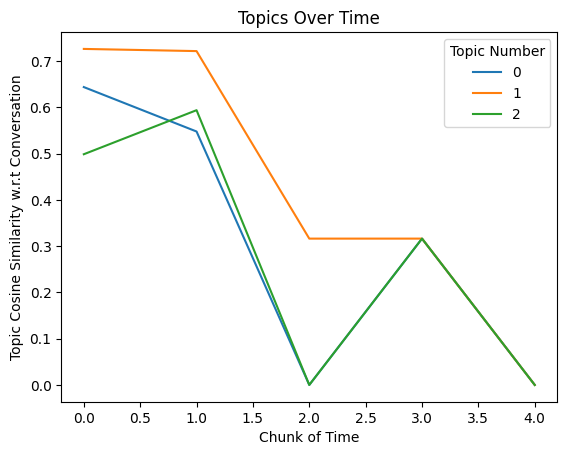

In [154]:
df_jury = df_jury[df_jury['conversation_num'] == 10]
get_topics_over_time(df_jury,5,3,top_topics)  # - Add a way to ensure that num_topics is less than topisc actually present